# Regression

## Classical Neuron

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Activation, Lambda
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input
import pickle

I0000 00:00:1784279384.407568  142401 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784279384.456297  142401 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784279385.658827  142401 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
# dataset definition
#reproducibility
np.random.seed(123456789)
true_quantum_params = (np.random.rand(4) )*np.pi
true_params = np.sin(true_quantum_params)

N = 100

x = np.linspace(0, 2*np.pi, N)
y = true_params[0] + np.sin(x)*true_params[1] + np.cos(x)*true_params[2] + np.sin(2*x)*true_params[3]
y_true = y.copy()
#adding noise
for i in range(N):
    y[i] +=  np.random.normal(loc=0.0, scale=0.1)

y_true /= y.max()
y /= y.max()

idx = np.arange(len(x))
np.random.shuffle(idx)

x_training = x[idx[:int(len(x)*0.8)]]
y_training = y[idx[:int(len(x)*0.8)]] 

x_test = x[idx[int(len(x)*0.8):]]
y_test = y[idx[int(len(x)*0.8):]]

# feature map
def feature_map(x):
    return np.column_stack([np.ones_like(x), np.sin(x), np.cos(x), np.sin(2*x), np.cos(2*x)])


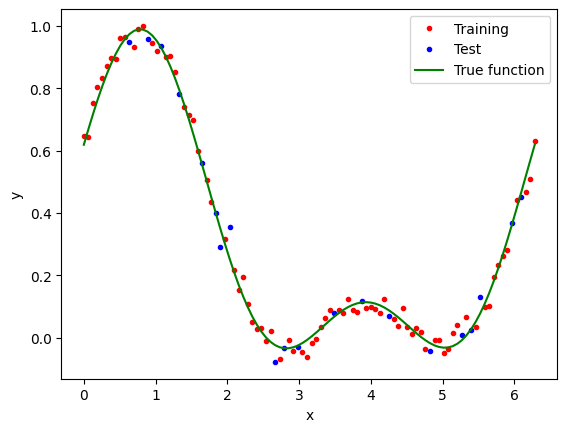

In [5]:
plt.plot(x_training, y_training, "r.", label="Training")
plt.plot(x_test, y_test, "b.", label="Test")
plt.plot(x, y_true, "g-", label="True function")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

In [5]:
#model definition
keras.utils.set_random_seed(42)
model = Sequential()

model.add(Dense(1, kernel_initializer='he_normal', use_bias=False, input_shape=(5,)))

model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

EPOCHS = 50
BATCH_SIZE = 1

fm_training = feature_map(x_training)
fm_test = feature_map(x_test)

fit = model.fit(fm_training, y_training,
                batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(fm_test, y_test),
                verbose=False,
                shuffle=True)



/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1784033996.903463    1263 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


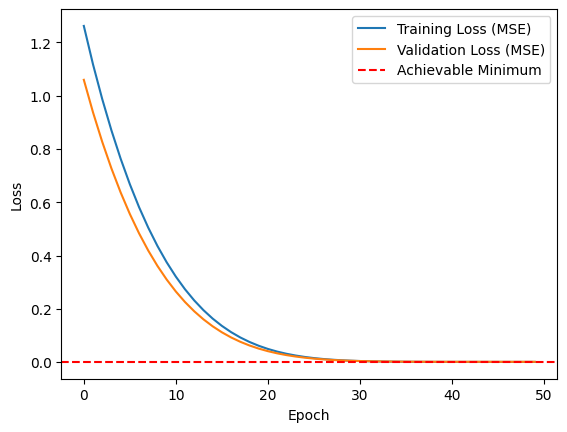

In [6]:
plt.plot(fit.history['loss'], label='Training Loss (MSE)')
plt.plot(fit.history['val_loss'], label='Validation Loss (MSE)')
plt.axhline(np.mean((y-y_true)**2)*0.5, ls="--", color= "red", label="Achievable Minimum")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 929us/step


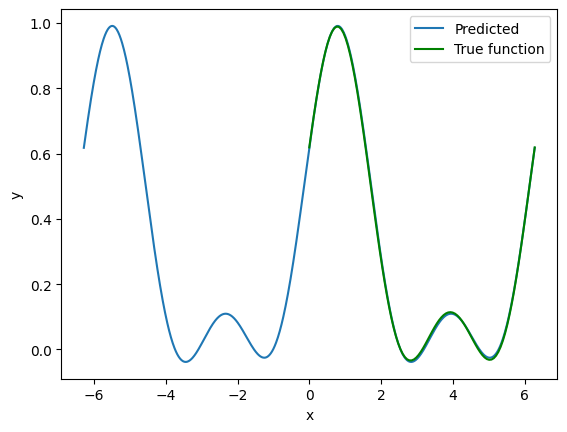

In [7]:
x_new = np.linspace(-2*np.pi, 2*np.pi, 1000)
y_pred = model.predict(feature_map(x_new))

plt.plot(x_new, y_pred, label="Predicted")
plt.plot(x, y_true, "g-", label="True function")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

### Multiple trainings

Addestramento modello 1/10...


/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Addestramento modello 2/10...
Addestramento modello 3/10...
Addestramento modello 4/10...
Addestramento modello 5/10...
Addestramento modello 6/10...
Addestramento modello 7/10...
Addestramento modello 8/10...
Addestramento modello 9/10...
Addestramento modello 10/10...


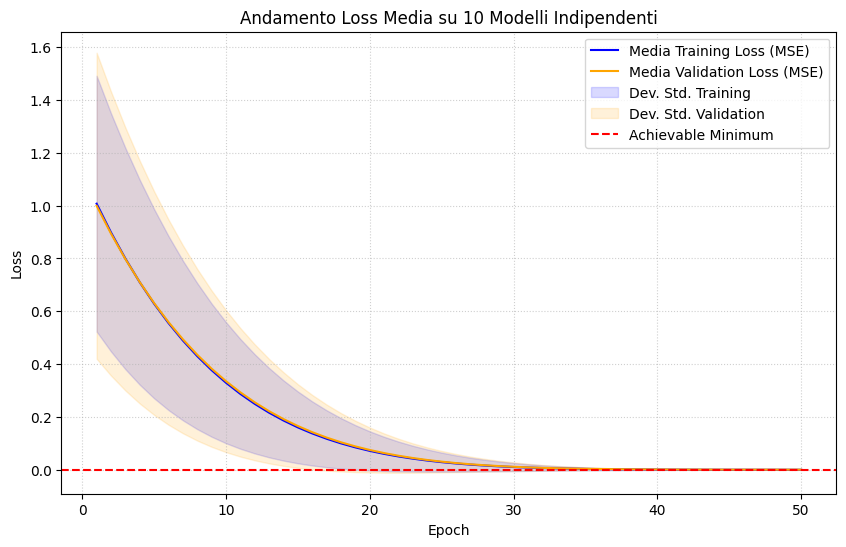

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.layers import Dense

# Configurazione
N_MODELS = 10
EPOCHS = 50
BATCH_SIZE = 1

# Matrice per salvare la loss di ogni modello ad ogni epoca
# Formato: (numero_modelli, numero_epoche)
all_train_losses = np.zeros((N_MODELS, EPOCHS))
all_val_losses = np.zeros((N_MODELS, EPOCHS))

# Mappiamo le feature una volta sola fuori dal ciclo
fm_training = feature_map(x_training)
fm_test = feature_map(x_test)

# Avvia il ciclo di addestramento
for i in range(N_MODELS):
    print(f"Addestramento modello {i+1}/{N_MODELS}...")
    
    # Pulizia della sessione per indipendenza e memoria
    keras.backend.clear_session()
    
    # Definizione del modello (i pesi verranno inizializzati casualmente a ogni ciclo)
    model = Sequential()
    model.add(Dense(1, kernel_initializer='he_normal', use_bias=False, input_shape=(5,)))
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # Addestramento
    fit = model.fit(fm_training, y_training,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(fm_test, y_test),
                    verbose=False,
                    shuffle=True)
    
    # Salvataggio della cronologia della loss
    all_train_losses[i, :] = fit.history['loss']
    all_val_losses[i, :] = fit.history['val_loss']

# Calcolo di media e deviazione standard lungo l'asse dei modelli (axis=0)
mean_train_loss = np.mean(all_train_losses, axis=0)
std_train_loss = np.std(all_train_losses, axis=0)

mean_val_loss = np.mean(all_val_losses, axis=0)
std_val_loss = np.std(all_val_losses, axis=0)

epochs_range = range(1, EPOCHS + 1)


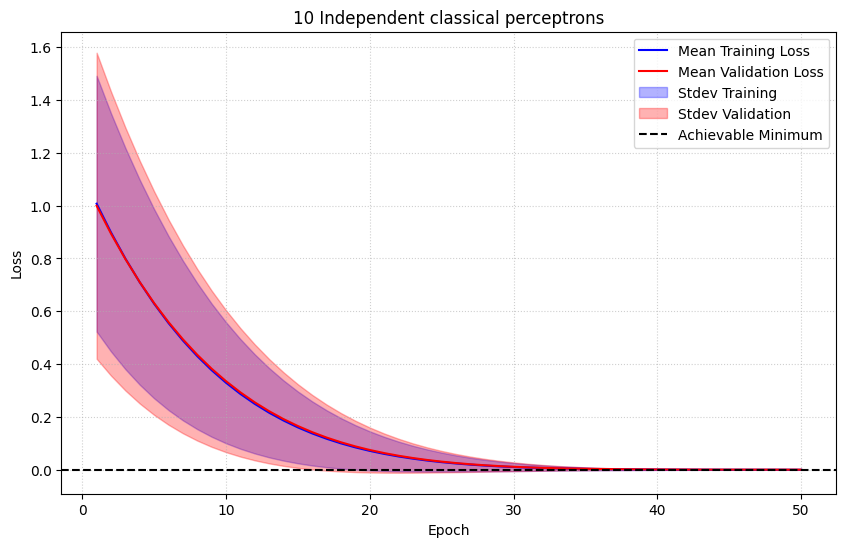

In [62]:

# Grafico dei risultati
plt.figure(figsize=(10, 6))

# Curve Medie
plt.plot(epochs_range, mean_train_loss, label='Mean Training Loss', color="blue")
plt.plot(epochs_range, mean_val_loss, label='Mean Validation Loss', color='red')

# Aree di Deviazione Standard (fill_between)
plt.fill_between(epochs_range, 
                 mean_train_loss - std_train_loss, 
                 mean_train_loss + std_train_loss, 
                 color='blue', alpha=0.3, label='Stdev Training')

plt.fill_between(epochs_range, 
                 mean_val_loss - std_val_loss, 
                 mean_val_loss + std_val_loss, 
                 color='red', alpha=0.3, label='Stdev Validation')

# Minimo teorico (se definito nel tuo script)
plt.axhline(np.mean((y-y_true)**2)*0.5, ls="--", color="k", label="Achievable Minimum")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{N_MODELS} Independent classical perceptrons")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


In [9]:
#save the model 
"""
with open("sinusoidal_classical_model.pkl", 'wb') as file:
    pickle.dump(model, file)
"""

'\nwith open("sinusoidal_classical_model.pkl", \'wb\') as file:\n    pickle.dump(model, file)\n'

## Quantum Neuron

### Utility

In [2]:
import qiskit
from qiskit import QuantumCircuit
from qiskit_algorithms.optimizers import SPSA, ADAM, COBYLA
from qiskit_machine_learning.algorithms.regressors import VQR
from qiskit_machine_learning.algorithms.classifiers import VQC
import qiskit_machine_learning.algorithms
from qiskit.primitives import StatevectorEstimator
from sklearn.preprocessing import StandardScaler
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN,  EffectiveDimension

In [6]:
#call back function for storing validation and training loss 
#I asked gemini to help me to write this class
class QuantumValidationCallback:
    def __init__(self, X_val, y_val):
        self.X_val = X_val
        self.y_val = y_val
        self.train_losses = []
        self.val_losses = []
        self.vqr = None  

    def __call__(self, nfev, weights, obj_func_eval, update_norm, accepted):
        
        self.train_losses.append(obj_func_eval)
        
        if self.vqr is None:
            print(f"no nome_callback.vqr = name_vqr provided")
            self.val_losses.append(None)
            return

        try:
            val_predictions = self.vqr.neural_network.forward(self.X_val, weights)
            
            val_loss = np.mean((val_predictions.flatten() - self.y_val.flatten()) ** 2)
            self.val_losses.append(val_loss)
            
            iteration = len(self.train_losses)
            print(f"Iter {iteration:03d} (Evals: {nfev}) | Train Loss: {obj_func_eval:.4f} | Val Loss: {val_loss:.4f}")
            
        except Exception as e:
            print(f"Error in the computation of the Validation Loss: {e}")
            self.val_losses.append(None)

In [7]:
#circuit builder
def QNN_builder(n_bits, featureMap, ansatz, depth=1):
    for i in range(depth):
        fm = featureMap(n_bits)
        a = ansatz(n_bits)
        qc = QuantumCircuit(n_bits)
        qc = qc.compose(fm.copy())
        qc = qc.compose(a.copy())

    return qc

#quantum ansatz
def quantum_ansatz(N):
    theta = ParameterVector('theta', 2*N)
    qc = QuantumCircuit(N)
    for i in range(N):
        qc.ry(theta[i], i)
   
    for i in range(N-1):
            for j in range(i+1,N):
                qc.cx(i, j)
                
    for i in range(N):
        qc.ry(theta[i+N], i)
    
    return qc

#classically implementable ansatz
def easy_ansatz(n_bits):
    theta = ParameterVector('theta', n_bits)
    qc = QuantumCircuit(n_bits)
    
    for i in range(n_bits):
        qc.ry(theta[i], i)
        
    return qc

#classically implementable feature map
def easy_feature_map(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    qc.barrier()
    return qc

#quantum feature map
def quantum_feature_map(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    for i in range(N):
        for j in range(i):
            qc.cx(j, i)
            qc.rz(x[j] * x[i], i)
            qc.cx(j, i)
        qc.barrier()
    return qc

### Quantum Classically Simulable Neuron
In the following plot you can see the Neuron we used. There is no entaglement, then it is classically simulable

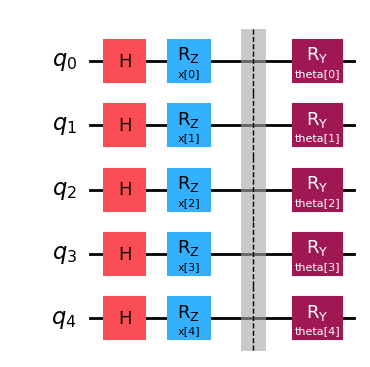

In [4]:
#quantum neuron (with entanglement)
circuit =  QNN_builder(5, easy_feature_map, easy_ansatz, depth=1)
circuit.draw("mpl")

In [52]:
#we prepare the data using the following function.
#As you can see it is different than the one we used for the classical neuron.
#If you think about the structure of the Bloch sphere,
#you see that applying an Hadamard to the circuit and an Rz which rotates
#the state by  x-pi/2 gives a projection along the x axis that is sin(x)
#Then ra rotazion x is cos(x) if projected and so on.
def quantum_data_transform(x): 
    return np.vstack([np.zeros_like(x), x-np.pi/2, x, 2*x-np.pi/2, 2*x]).T

SEED = 42
np.random.seed(SEED)


_original_default_rng = np.random.default_rng

#Preparing data    
fm_training = quantum_data_transform(x_training)
fm_test = quantum_data_transform(x_test)

validation_callback = QuantumValidationCallback(fm_test, y_test)    
training_loss = []
validation_loss = []

#Defininig the quantum neuron
optimizer = SPSA(maxiter=100)
estimator  = StatevectorEstimator(seed=42)


#This is like measuring Z separately on each quantum line
observable = SparsePauliOp.from_sparse_list(
    [("Z", [i], 1.0) for i in range(5)], 
    num_qubits=5
)

num_parameters = a.num_parameters
initial_point = np.random.uniform(-np.pi, np.pi, num_parameters)

fm = easy_feature_map(5)
a = easy_ansatz(5)
vqr = VQR(
    estimator=estimator,
    feature_map=fm,
    ansatz=a,
    optimizer=optimizer,
    observable=observable,
    callback=validation_callback,   
    initial_point=initial_point
)

validation_callback.vqr = vqr

vqr.fit(fm_training, y_training)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Iter 001 (Evals: 3) | Train Loss: 1.7695 | Val Loss: 1.9437
Iter 002 (Evals: 6) | Train Loss: 1.4928 | Val Loss: 1.6404
Iter 003 (Evals: 9) | Train Loss: 1.4923 | Val Loss: 1.6381
Iter 004 (Evals: 12) | Train Loss: 1.3377 | Val Loss: 1.3726
Iter 005 (Evals: 15) | Train Loss: 1.3358 | Val Loss: 1.3655
Iter 006 (Evals: 18) | Train Loss: 1.2639 | Val Loss: 1.2920
Iter 007 (Evals: 21) | Train Loss: 1.2584 | Val Loss: 1.2782
Iter 008 (Evals: 24) | Train Loss: 1.2507 | Val Loss: 1.2807
Iter 009 (Evals: 27) | Train Loss: 1.2112 | Val Loss: 1.2654
Iter 010 (Evals: 30) | Train Loss: 1.0972 | Val Loss: 1.1472
Iter 011 (Evals: 33) | Train Loss: 1.0927 | Val Loss: 1.1305
Iter 012 (Evals: 36) | Train Loss: 1.0905 | Val Loss: 1.1316
Iter 013 (Evals: 39) | Train Loss: 1.0789 | Val Loss: 1.1256
Iter 014 (Evals: 42) | Train Loss: 0.9786 | Val Loss: 1.0134
Iter 015 (Evals: 45) | Train Loss: 0.9488 | Val Loss: 0.9953
Iter 016 (Evals: 48) | Train Loss: 0.9445 | Val Loss: 0.9831
Iter 017 (Evals: 51) | Trai

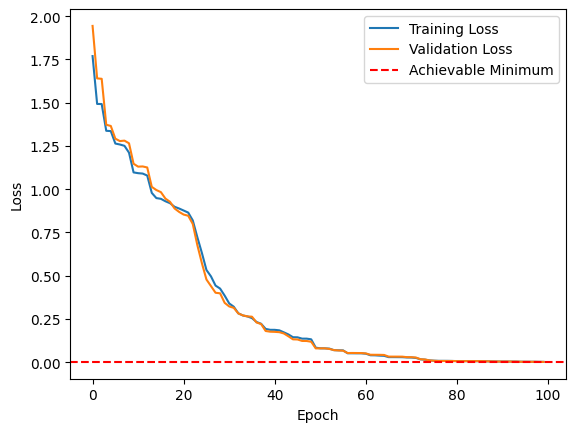

In [53]:
plt.plot(validation_callback.train_losses, label="Training Loss")
plt.plot(validation_callback.val_losses, label="Validation Loss")
plt.axhline(np.mean((y-y_true)**2)*0.5, ls="--", color= "red", label="Achievable Minimum")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

In [44]:
#saving the model to file
model_data = {
        'weights': vqr.weights
    }

with open('easy_vqr_sinusoidal_model.pkl', 'wb') as f:
        pickle.dump(model_data, f)
    

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


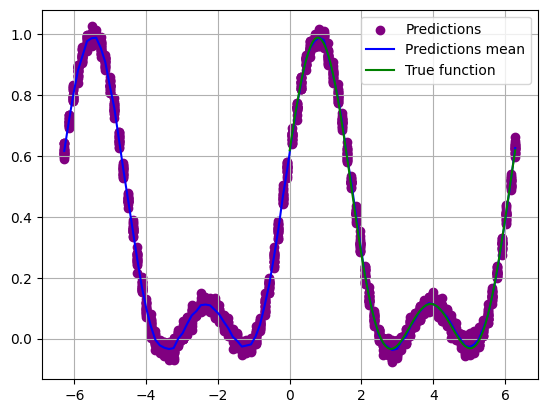

In [10]:
#importing the model 
with open('easy_vqr_sinusoidal_model.pkl', 'rb') as f:
    model_data = pickle.load(f)

weights =  model_data['weights']

#dummy optimizer used to reconstruct the model without change its parameters
dummy_optimizer = SPSA(maxiter=0)
estimator = StatevectorEstimator()

fm = easy_feature_map(5)
a = easy_ansatz(5)

observable = SparsePauliOp.from_sparse_list(
    [("Z", [i], 1.0) for i in range(5)], 
    num_qubits=5
)

vqr_loaded = VQR(
    estimator=estimator,
    feature_map=fm,
    ansatz=a,
    optimizer=dummy_optimizer,
    observable=observable,
    initial_point=weights
)

#fake fit of data (actually no fit is performed)
vqr_loaded.fit(np.zeros((1, 5)), np.zeros(1))

#generate new data
new_x = np.linspace(-2*np.pi, 2*np.pi, 100) 
fm_new_scaled = quantum_data_transform(new_x)

#predict the value for y
y_pred = []
prediction_number = 20
for _ in range(prediction_number):
    y_pred_norm = vqr_loaded.predict(fm_new_scaled)
    y_pred.append(y_pred_norm)

y_pred = np.array(y_pred)
plt.scatter([new_x]*prediction_number, y_pred, color='purple', label="Predictions")

#mean value of the prediction 
y_mean = np.mean(y_pred, axis=0)
plt.plot(new_x, y_mean, color='blue', label="Predictions mean")
plt.plot(x, y_true, "g-", label="True function")
plt.legend()
plt.grid()
plt.show()

### Multiple trainings

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Addestramento modello quantistico 1/10...
Iter 001 (Evals: 3) | Train Loss: 1.7841 | Val Loss: 1.8853
Iter 002 (Evals: 6) | Train Loss: 0.5552 | Val Loss: 0.7025
Iter 003 (Evals: 9) | Train Loss: 0.4439 | Val Loss: 0.4718
Iter 004 (Evals: 12) | Train Loss: 0.4335 | Val Loss: 0.5115
Iter 005 (Evals: 15) | Train Loss: 0.4047 | Val Loss: 0.4745
Iter 006 (Evals: 18) | Train Loss: 0.3894 | Val Loss: 0.4413
Iter 007 (Evals: 21) | Train Loss: 0.3920 | Val Loss: 0.4353
Iter 008 (Evals: 24) | Train Loss: 0.3900 | Val Loss: 0.4402
Iter 009 (Evals: 27) | Train Loss: 0.3860 | Val Loss: 0.4453
Iter 010 (Evals: 30) | Train Loss: 0.3492 | Val Loss: 0.3989
Iter 011 (Evals: 33) | Train Loss: 0.3365 | Val Loss: 0.3799
Iter 012 (Evals: 36) | Train Loss: 0.2880 | Val Loss: 0.3390
Iter 013 (Evals: 39) | Train Loss: 0.2703 | Val Loss: 0.3119
Iter 014 (Evals: 42) | Train Loss: 0.2723 | Val Loss: 0.3030
Iter 015 (Evals: 45) | Train Loss: 0.2679 | Val Loss: 0.2912
Iter 016 (Evals: 48) | Train Loss: 0.2583 | Va

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Iter 100 (Evals: 300) | Train Loss: 0.0009 | Val Loss: 0.0014
Addestramento modello quantistico 2/10...
Iter 001 (Evals: 3) | Train Loss: 1.4667 | Val Loss: 1.6022
Iter 002 (Evals: 6) | Train Loss: 1.3478 | Val Loss: 1.3439
Iter 003 (Evals: 9) | Train Loss: 1.3039 | Val Loss: 1.3859
Iter 004 (Evals: 12) | Train Loss: 0.5886 | Val Loss: 0.5327
Iter 005 (Evals: 15) | Train Loss: 0.5856 | Val Loss: 0.5239
Iter 006 (Evals: 18) | Train Loss: 0.4656 | Val Loss: 0.4703
Iter 007 (Evals: 21) | Train Loss: 0.4674 | Val Loss: 0.4626
Iter 008 (Evals: 24) | Train Loss: 0.3068 | Val Loss: 0.3010
Iter 009 (Evals: 27) | Train Loss: 0.3030 | Val Loss: 0.3175
Iter 010 (Evals: 30) | Train Loss: 0.2380 | Val Loss: 0.2336
Iter 011 (Evals: 33) | Train Loss: 0.0905 | Val Loss: 0.0884
Iter 012 (Evals: 36) | Train Loss: 0.0908 | Val Loss: 0.0859
Iter 013 (Evals: 39) | Train Loss: 0.0830 | Val Loss: 0.0769
Iter 014 (Evals: 42) | Train Loss: 0.0843 | Val Loss: 0.0758
Iter 015 (Evals: 45) | Train Loss: 0.0842 | V

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


...

Iter 100 (Evals: 300) | Train Loss: 0.0010 | Val Loss: 0.0013
Addestramento modello quantistico 8/10...
Iter 001 (Evals: 3) | Train Loss: 0.9513 | Val Loss: 0.8388
Iter 002 (Evals: 6) | Train Loss: 0.7571 | Val Loss: 0.9318
Iter 003 (Evals: 9) | Train Loss: 0.6924 | Val Loss: 0.7729
Iter 004 (Evals: 12) | Train Loss: 0.6759 | Val Loss: 0.6984
Iter 005 (Evals: 15) | Train Loss: 0.6599 | Val Loss: 0.6616
Iter 006 (Evals: 18) | Train Loss: 0.5973 | Val Loss: 0.5762
Iter 007 (Evals: 21) | Train Loss: 0.4215 | Val Loss: 0.4483
Iter 008 (Evals: 24) | Train Loss: 0.2599 | Val Loss: 0.2333
Iter 009 (Evals: 27) | Train Loss: 0.2268 | Val Loss: 0.2223
Iter 010 (Evals: 30) | Train Loss: 0.1725 | Val Loss: 0.1881
Iter 011 (Evals: 33) | Train Loss: 0.0687 | Val Loss: 0.0885
Iter 012 (Evals: 36) | Train Loss: 0.0613 | Val Loss: 0.0823
Iter 013 (Evals: 39) | Train Loss: 0.0386 | Val Loss: 0.0460
Iter 014 (Evals: 42) | Train Loss: 0.0349 | Val Loss: 0.0396
Iter 015 (Evals: 45) | Train Loss: 0.0240 | V

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Iter 100 (Evals: 300) | Train Loss: 0.0010 | Val Loss: 0.0015
Addestramento modello quantistico 9/10...
Iter 001 (Evals: 3) | Train Loss: 2.2178 | Val Loss: 1.9987
Iter 002 (Evals: 6) | Train Loss: 2.1731 | Val Loss: 1.9813
Iter 003 (Evals: 9) | Train Loss: 1.8287 | Val Loss: 1.8374
Iter 004 (Evals: 12) | Train Loss: 1.5582 | Val Loss: 1.4225
Iter 005 (Evals: 15) | Train Loss: 0.6399 | Val Loss: 0.6232
Iter 006 (Evals: 18) | Train Loss: 0.4123 | Val Loss: 0.4611
Iter 007 (Evals: 21) | Train Loss: 0.3339 | Val Loss: 0.3761
Iter 008 (Evals: 24) | Train Loss: 0.2178 | Val Loss: 0.2051
Iter 009 (Evals: 27) | Train Loss: 0.2136 | Val Loss: 0.2041
Iter 010 (Evals: 30) | Train Loss: 0.1897 | Val Loss: 0.1685
Iter 011 (Evals: 33) | Train Loss: 0.1709 | Val Loss: 0.1464
Iter 012 (Evals: 36) | Train Loss: 0.1731 | Val Loss: 0.1487
Iter 013 (Evals: 39) | Train Loss: 0.1712 | Val Loss: 0.1492
Iter 014 (Evals: 42) | Train Loss: 0.1694 | Val Loss: 0.1421
Iter 015 (Evals: 45) | Train Loss: 0.1394 | V

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Iter 100 (Evals: 300) | Train Loss: 0.0014 | Val Loss: 0.0018
Addestramento modello quantistico 10/10...
Iter 001 (Evals: 3) | Train Loss: 1.9111 | Val Loss: 1.5512
Iter 002 (Evals: 6) | Train Loss: 1.5749 | Val Loss: 1.7169
Iter 003 (Evals: 9) | Train Loss: 0.7651 | Val Loss: 0.6538
Iter 004 (Evals: 12) | Train Loss: 0.4722 | Val Loss: 0.4075
Iter 005 (Evals: 15) | Train Loss: 0.4706 | Val Loss: 0.4066
Iter 006 (Evals: 18) | Train Loss: 0.4703 | Val Loss: 0.3934
Iter 007 (Evals: 21) | Train Loss: 0.4076 | Val Loss: 0.3490
Iter 008 (Evals: 24) | Train Loss: 0.1403 | Val Loss: 0.1636
Iter 009 (Evals: 27) | Train Loss: 0.1360 | Val Loss: 0.1308
Iter 010 (Evals: 30) | Train Loss: 0.1122 | Val Loss: 0.1332
Iter 011 (Evals: 33) | Train Loss: 0.0363 | Val Loss: 0.0426
Iter 012 (Evals: 36) | Train Loss: 0.0341 | Val Loss: 0.0400
Iter 013 (Evals: 39) | Train Loss: 0.0253 | Val Loss: 0.0315
Iter 014 (Evals: 42) | Train Loss: 0.0259 | Val Loss: 0.0314
Iter 015 (Evals: 45) | Train Loss: 0.0100 | 

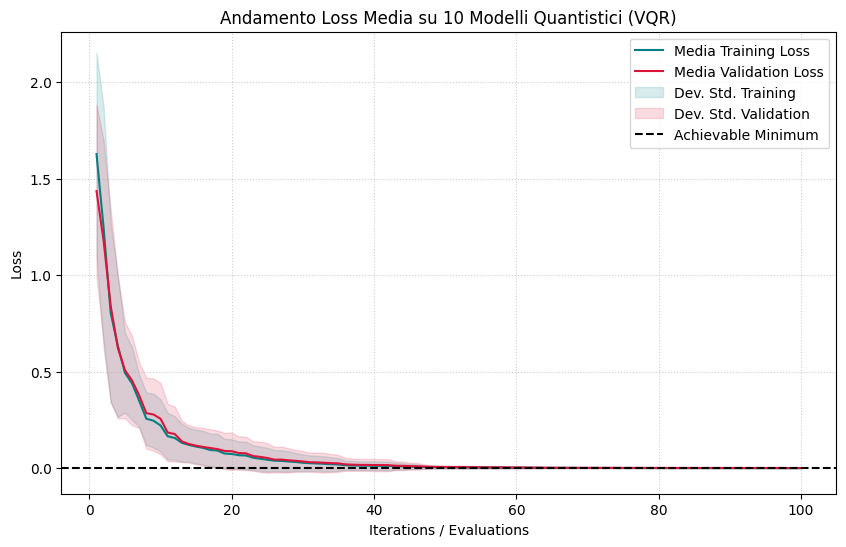

In [63]:
import numpy as np
import matplotlib.pyplot as plt


N_MODELS = 10
MAX_ITER = 100  

fm_training = quantum_data_transform(x_training)
fm_test = quantum_data_transform(x_test)

all_train_losses = np.zeros((N_MODELS, MAX_ITER))
all_val_losses = np.zeros((N_MODELS, MAX_ITER))

fm = easy_feature_map(5)
a = easy_ansatz(5)
num_parameters = a.num_parameters

observable = SparsePauliOp.from_sparse_list(
    [("Z", [i], 1.0) for i in range(5)], 
    num_qubits=5
)

for i in range(N_MODELS):
    print(f"Addestramento modello quantistico {i+1}/{N_MODELS}...")
    
    initial_point = np.random.uniform(-np.pi, np.pi, num_parameters)
    
    estimator = StatevectorEstimator() 
    optimizer = SPSA(maxiter=MAX_ITER)
    
    validation_callback = QuantumValidationCallback(fm_test, y_test)
    
    vqr = VQR(
        estimator=estimator,
        feature_map=fm,
        ansatz=a,
        optimizer=optimizer,
        observable=observable,
        callback=validation_callback,   
        initial_point=initial_point
    )
    
    validation_callback.vqr = vqr
    
    vqr.fit(fm_training, y_training)
    
    all_train_losses[i, :] = validation_callback.train_losses[:MAX_ITER]
    all_val_losses[i, :] = validation_callback.val_losses[:MAX_ITER]

mean_train_loss = np.mean(all_train_losses, axis=0)
std_train_loss = np.std(all_train_losses, axis=0)

mean_val_loss = np.mean(all_val_losses, axis=0)
std_val_loss = np.std(all_val_losses, axis=0)

iterations_range = range(1, MAX_ITER + 1)



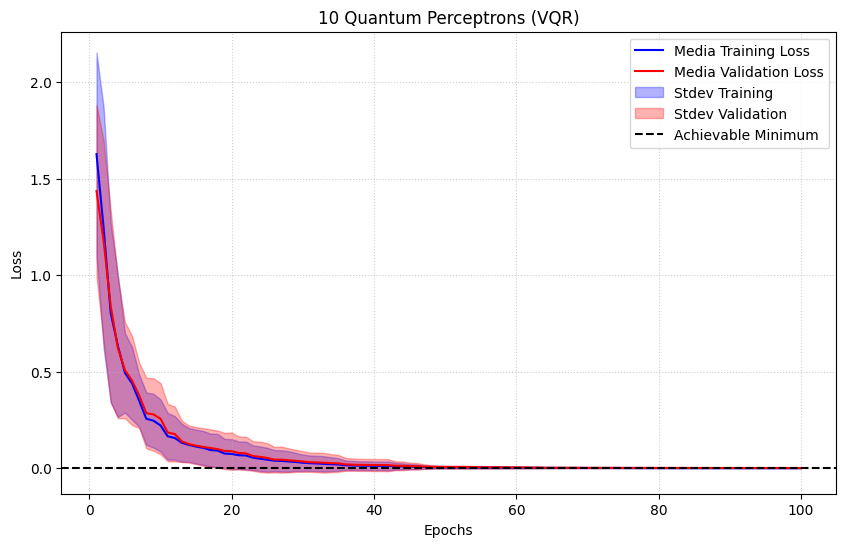

In [66]:
plt.figure(figsize=(10, 6))


plt.plot(iterations_range, mean_train_loss, label='Media Training Loss', color='blue')
plt.plot(iterations_range, mean_val_loss, label='Media Validation Loss', color='red')


plt.fill_between(iterations_range, 
                 mean_train_loss - std_train_loss, 
                 mean_train_loss + std_train_loss, 
                 color='blue', alpha=0.3, label='Stdev Training')

plt.fill_between(iterations_range, 
                 mean_val_loss - std_val_loss, 
                 mean_val_loss + std_val_loss, 
                 color='red', alpha=0.3,
                 label='Stdev Validation')


plt.axhline(np.mean((y-y_true)**2)*0.5, ls="--", color="black", label="Achievable Minimum")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title(f"{N_MODELS} Quantum Perceptrons (VQR)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Quantum Not Classically Simulable Neuron

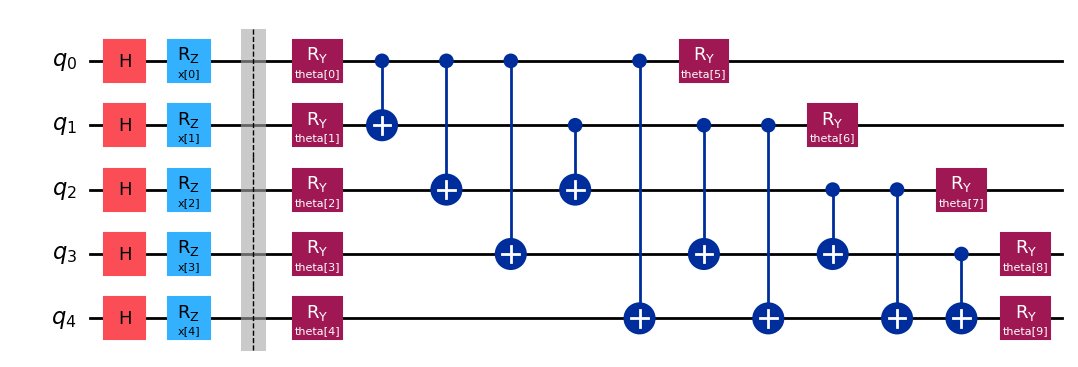

In [13]:
#quantum neuron (with entanglement)
circuit =  QNN_builder(5, easy_feature_map, quantum_ansatz, depth=1)
circuit.draw("mpl")


In [86]:
#we prepare the data using the following function.
#As you can see it is different than the one we used for the classical neuron.
#If you think about the structure of the Bloch sphere,
#you see that applying an Hadamard to the circuit and an Rz which rotates
#the state by  x-pi/2 gives a projection along the x axis that is sin(x)
#Then ra rotazion x is cos(x) if projected and so on.
def quantum_data_transform(x): 
    return np.vstack([np.zeros_like(x), x-np.pi/2, x, 2*x-np.pi/2, 2*x]).T

#Preparing data    
fm_training = quantum_data_transform(x_training)
fm_test = quantum_data_transform(x_test)

validation_callback = QuantumValidationCallback(fm_test, y_test)    
training_loss = []
validation_loss = []

#Defininig the quantum neuron
optimizer = SPSA(maxiter=150)
estimator = StatevectorEstimator()

#This is like measuring Z separately on each quantum line
observable = SparsePauliOp.from_sparse_list(
    [("Z", [i], 1.0) for i in range(5)], 
    num_qubits=5
)

fm = easy_feature_map(5)
a = quantum_ansatz(5)
vqr = VQR(
    estimator=estimator,
    feature_map=fm,
    ansatz=a,
    optimizer=optimizer,
    #observable=observable,
    callback=validation_callback    
)

validation_callback.vqr = vqr

vqr.fit(fm_training, y_training)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Iter 001 (Evals: 3) | Train Loss: 0.2751 | Val Loss: 0.2643
Iter 002 (Evals: 6) | Train Loss: 0.1987 | Val Loss: 0.1742
Iter 003 (Evals: 9) | Train Loss: 0.2304 | Val Loss: 0.2050
Iter 004 (Evals: 12) | Train Loss: 0.2308 | Val Loss: 0.2048
Iter 005 (Evals: 15) | Train Loss: 0.2247 | Val Loss: 0.2207
Iter 006 (Evals: 18) | Train Loss: 0.2237 | Val Loss: 0.2279
Iter 007 (Evals: 21) | Train Loss: 0.2207 | Val Loss: 0.2186
Iter 008 (Evals: 24) | Train Loss: 0.2167 | Val Loss: 0.2131
Iter 009 (Evals: 27) | Train Loss: 0.2054 | Val Loss: 0.2101
Iter 010 (Evals: 30) | Train Loss: 0.2056 | Val Loss: 0.1801
Iter 011 (Evals: 33) | Train Loss: 0.2035 | Val Loss: 0.1817
Iter 012 (Evals: 36) | Train Loss: 0.2065 | Val Loss: 0.1879
Iter 013 (Evals: 39) | Train Loss: 0.2021 | Val Loss: 0.1765
Iter 014 (Evals: 42) | Train Loss: 0.1988 | Val Loss: 0.1740
Iter 015 (Evals: 45) | Train Loss: 0.2001 | Val Loss: 0.1759
Iter 016 (Evals: 48) | Train Loss: 0.1977 | Val Loss: 0.1782
Iter 017 (Evals: 51) | Trai

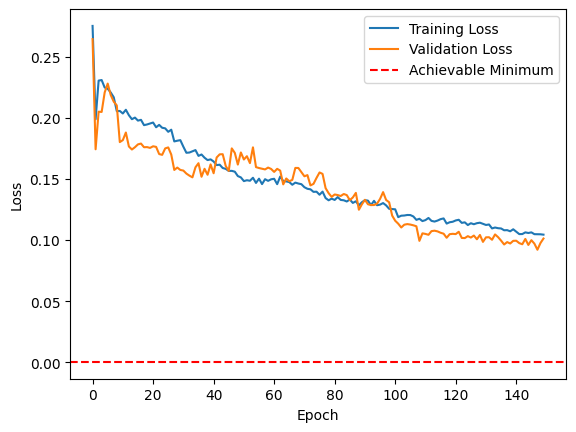

In [87]:
plt.plot(validation_callback.train_losses, label="Training Loss")
plt.plot(validation_callback.val_losses, label="Validation Loss")
plt.axhline(np.mean((y-y_true)**2)*0.5, ls="--", color= "red", label="Achievable Minimum")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

In [88]:
#saving the model to file
model_data = {
        'weights': vqr.weights
    }

with open('quantum_vqr_sinusoidal_model.pkl', 'wb') as f:
        pickle.dump(model_data, f)
    

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


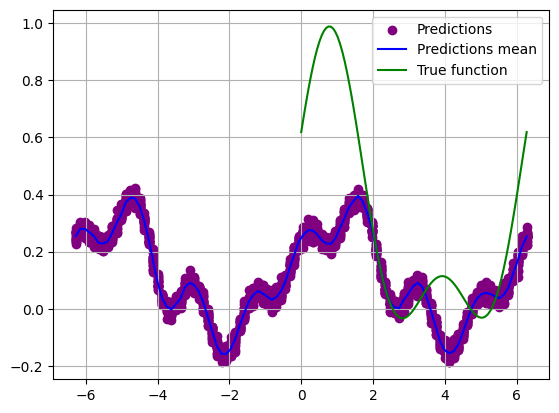

In [20]:
#importing the model 
with open('quantum_vqr_sinusoidal_model.pkl', 'rb') as f:
    model_data = pickle.load(f)

weights =  model_data['weights']

#dummy optimizer used to reconstruct the model without change its parameters
dummy_optimizer = SPSA(maxiter=0)
estimator = StatevectorEstimator()

fm = easy_feature_map(5)
a = quantum_ansatz(5)

observable = SparsePauliOp.from_sparse_list(
    [("Z", [i], 1.0) for i in range(5)], 
    num_qubits=5
)

vqr_loaded = VQR(
    estimator=estimator,
    feature_map=fm,
    ansatz=a,
    optimizer=dummy_optimizer,
    #observable=observable,
    initial_point=weights
)

#fake fit of data (actually no fit is performed)
vqr_loaded.fit(np.zeros((1, 5)), np.zeros(1))

#generate new data
new_x = np.linspace(-2*np.pi, 2*np.pi, 100) 
fm_new_scaled = quantum_data_transform(new_x)

#predict the value for y
y_pred = []
prediction_number = 20
for _ in range(prediction_number):
    y_pred_norm = vqr_loaded.predict(fm_new_scaled)
    y_pred.append(y_pred_norm)

y_pred = np.array(y_pred)
plt.scatter([new_x]*prediction_number, y_pred, color='purple', label="Predictions")

#mean value of the prediction 
y_mean = np.mean(y_pred, axis=0)
plt.plot(new_x, y_mean, color='blue', label="Predictions mean")
plt.plot(x, y_true, "g-", label="True function")
plt.legend()
plt.grid()
plt.show()

### QNN

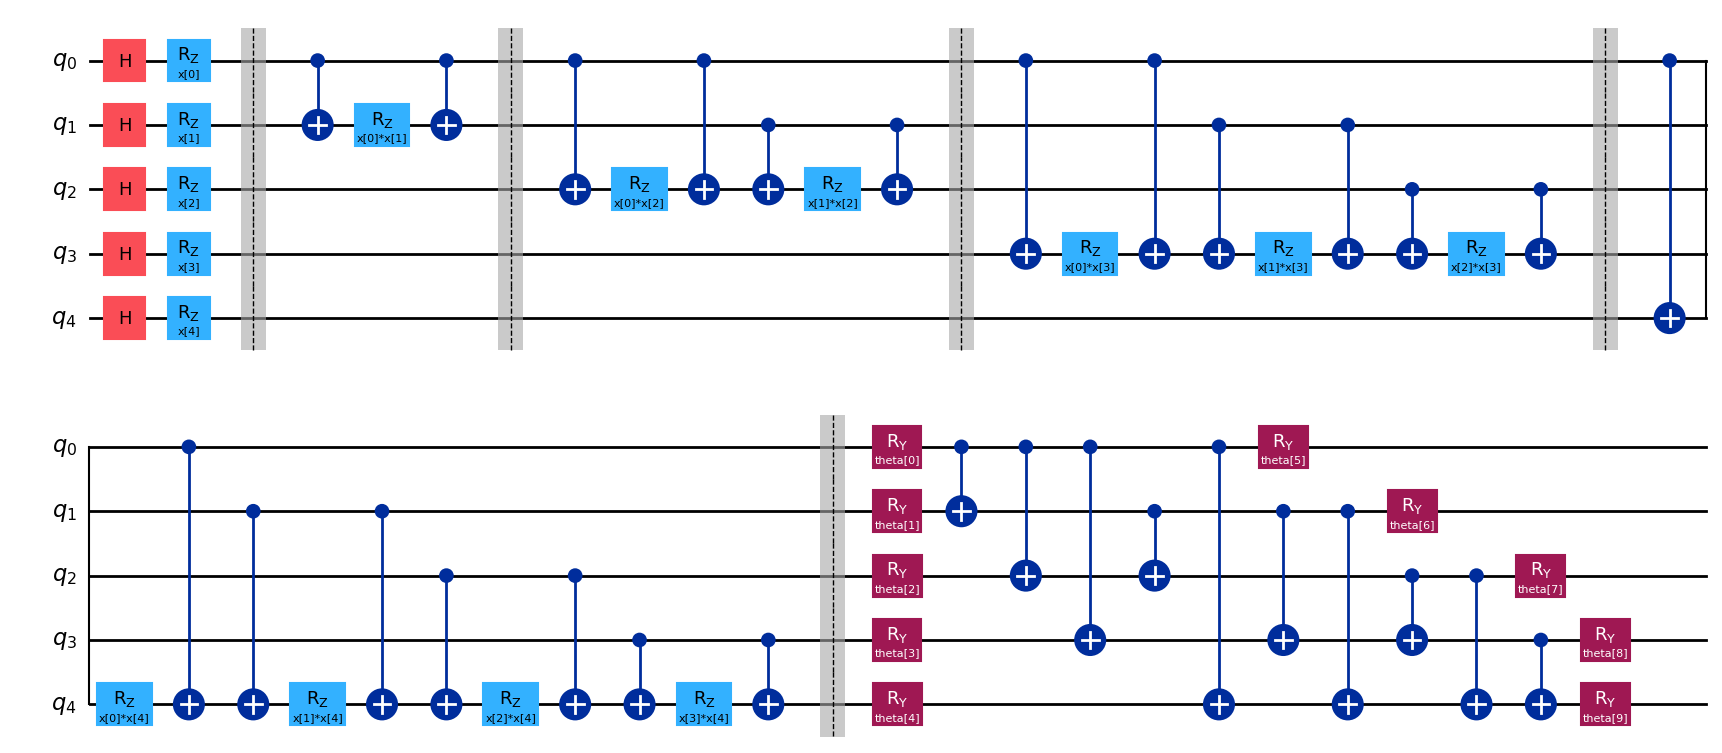

In [21]:
#quantum neuron (with entanglement)
circuit =  QNN_builder(5, quantum_feature_map, quantum_ansatz, depth=1)
circuit.draw("mpl")

In [22]:
#we prepare the data using the following function.
#As you can see it is different than the one we used for the classical neuron.
#If you think about the structure of the Bloch sphere,
#you see that applying an Hadamard to the circuit and an Rz which rotates
#the state by  x-pi/2 gives a projection along the x axis that is sin(x)
#Then ra rotazion x is cos(x) if projected and so on.
def quantum_data_transform(x): 
    return np.vstack([np.zeros_like(x), x-np.pi/2, x, 2*x-np.pi/2, 2*x]).T

#Preparing data    
fm_training = quantum_data_transform(x_training)
fm_test = quantum_data_transform(x_test)

validation_callback = QuantumValidationCallback(fm_test, y_test)    
training_loss = []
validation_loss = []

#Defininig the quantum neuron
optimizer = SPSA(maxiter=150)
estimator = StatevectorEstimator()

fm = quantum_feature_map(5)
a = quantum_ansatz(5)
vqr = VQR(
    estimator=estimator,
    feature_map=fm,
    ansatz=a,
    optimizer=optimizer,
    callback=validation_callback    
)

validation_callback.vqr = vqr

vqr.fit(fm_training, y_training)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Iter 001 (Evals: 3) | Train Loss: 0.2650 | Val Loss: 0.1595
Iter 002 (Evals: 6) | Train Loss: 0.3159 | Val Loss: 0.2767
Iter 003 (Evals: 9) | Train Loss: 0.2205 | Val Loss: 0.2630
Iter 004 (Evals: 12) | Train Loss: 0.1990 | Val Loss: 0.2569
Iter 005 (Evals: 15) | Train Loss: 0.1892 | Val Loss: 0.2319
Iter 006 (Evals: 18) | Train Loss: 0.1521 | Val Loss: 0.1857
Iter 007 (Evals: 21) | Train Loss: 0.1478 | Val Loss: 0.1844
Iter 008 (Evals: 24) | Train Loss: 0.1332 | Val Loss: 0.1767
Iter 009 (Evals: 27) | Train Loss: 0.1373 | Val Loss: 0.1754
Iter 010 (Evals: 30) | Train Loss: 0.1252 | Val Loss: 0.1666
Iter 011 (Evals: 33) | Train Loss: 0.1207 | Val Loss: 0.1545
Iter 012 (Evals: 36) | Train Loss: 0.1023 | Val Loss: 0.1134
Iter 013 (Evals: 39) | Train Loss: 0.0949 | Val Loss: 0.1068
Iter 014 (Evals: 42) | Train Loss: 0.0908 | Val Loss: 0.1165
Iter 015 (Evals: 45) | Train Loss: 0.0909 | Val Loss: 0.1120
Iter 016 (Evals: 48) | Train Loss: 0.0842 | Val Loss: 0.1194
Iter 017 (Evals: 51) | Trai

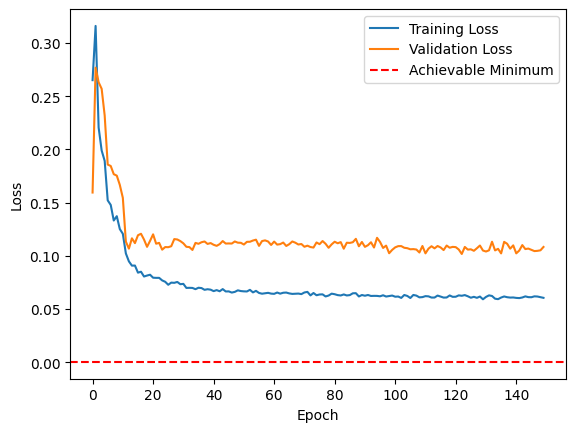

In [24]:
plt.plot(validation_callback.train_losses, label="Training Loss")
plt.plot(validation_callback.val_losses, label="Validation Loss")
plt.axhline(np.mean((y-y_true)**2)*0.5, ls="--", color= "red", label="Achievable Minimum")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

In [25]:
#saving the model to file
model_data = {
        'weights': vqr.weights
    }

with open('quantum_vqr_qnn_sinusoidal_model.pkl', 'wb') as f:
        pickle.dump(model_data, f)
    

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


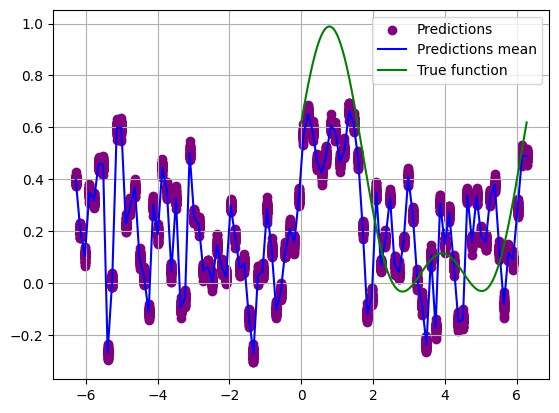

In [28]:
#importing the model 
with open('quantum_vqr_qnn_sinusoidal_model.pkl', 'rb') as f:
    model_data = pickle.load(f)

weights =  model_data['weights']

#dummy optimizer used to reconstruct the model without change its parameters
dummy_optimizer = SPSA(maxiter=0)
estimator = StatevectorEstimator()

fm = quantum_feature_map(5)
a = quantum_ansatz(5)

observable = SparsePauliOp.from_sparse_list(
    [("Z", [i], 1.0) for i in range(5)], 
    num_qubits=5
)

vqr_loaded = VQR(
    estimator=estimator,
    feature_map=fm,
    ansatz=a,
    optimizer=dummy_optimizer,
    #observable=observable,
    initial_point=weights
)

#fake fit of data (actually no fit is performed)
vqr_loaded.fit(np.zeros((1, 5)), np.zeros(1))

#generate new data
new_x = np.linspace(-2*np.pi, 2*np.pi, 100) 
fm_new_scaled = quantum_data_transform(new_x)

#predict the value for y
y_pred = []
prediction_number = 50
for _ in range(prediction_number):
    y_pred_norm = vqr_loaded.predict(fm_new_scaled)
    y_pred.append(y_pred_norm)

y_pred = np.array(y_pred)
plt.scatter([new_x]*prediction_number, y_pred, color='purple', label="Predictions")

#mean value of the prediction 
y_mean = np.mean(y_pred, axis=0)
plt.plot(new_x, y_mean, color='blue', label="Predictions mean")
plt.plot(x, y_true, "g-", label="True function")
plt.legend()
plt.grid()
plt.show()

## Computing Effective Dimension

In [16]:
#Classical wrapper to make the Keras model compatible with the qiskit's effective dimension class
import numpy as np
from qiskit_machine_learning.neural_networks import NeuralNetwork


class ClassicalNNWrapper(NeuralNetwork):
    
    def __init__(self, keras_model, n_inputs: int, n_outputs: int,
                 input_gradients: bool = True, output_activation: str | None = None):
       
        self._model = keras_model
        self._output_activation = output_activation

        #to handle different architectures
        num_weights = int(keras_model.count_params())

        #saving weights shape and size
        self._weight_shapes = [w.shape for w in keras_model.get_weights()]
        self._weight_sizes = [int(np.prod(s)) for s in self._weight_shapes]

        super().__init__(
            num_inputs=n_inputs,
            num_weights=num_weights,
            sparse=False,
            output_shape=(n_outputs,),
            input_gradients=input_gradients,
        )

   
    def _weights_vector_to_keras_list(self, weights_flat: np.ndarray):
        weights_flat = np.asarray(weights_flat).reshape(-1)
        out = []
        idx = 0
        for shape, size in zip(self._weight_shapes, self._weight_sizes):
            chunk = weights_flat[idx: idx + size]
            out.append(chunk.reshape(shape))
            idx += size
        return out

   
    def _raw_forward(self, input_data: np.ndarray) -> np.ndarray:
        return self._model.predict(input_data, verbose=0)

    def _apply_output_activation(self, raw_output: np.ndarray) -> np.ndarray:
        if self._output_activation is None:
            return raw_output
        if self._output_activation == "sigmoid":
            return 1.0 / (1.0 + np.exp(-raw_output))
        

    def _forward(self, input_data: np.ndarray, weights: np.ndarray) -> np.ndarray:
        self._model.set_weights(self._weights_vector_to_keras_list(weights))
        raw_output = self._raw_forward(input_data)
        return self._apply_output_activation(raw_output)

    #model's backward
    def _backward(self, input_data: np.ndarray, weights: np.ndarray):
        
        self._model.set_weights(self._weights_vector_to_keras_list(weights))

        n = input_data.shape[0]
        output_size = self.output_shape[0]

       
        base_grad = np.repeat(input_data[:, np.newaxis, :], output_size, axis=1)

        if self._output_activation is None:
            weight_grad = base_grad
        elif self._output_activation == "sigmoid":
            raw_output = self._raw_forward(input_data)            
            sig = self._apply_output_activation(raw_output)         
            sig_derivative = sig * (1.0 - sig)                        
            weight_grad = base_grad * sig_derivative[:, :, np.newaxis]
        

        input_grad = None
        if self.input_gradients:
            w = self._model.get_weights()[0]  
            base_input_grad = np.repeat(w.T[np.newaxis, :, :], n, axis=0)  
            if self._output_activation is None:
                input_grad = base_input_grad
            else:
                raw_output = self._raw_forward(input_data)
                sig = self._apply_output_activation(raw_output)
                sig_derivative = sig * (1.0 - sig)
                input_grad = base_input_grad * sig_derivative[:, :, np.newaxis]

        return input_grad, weight_grad

In [17]:
def make_estimator_qnn(circ, use_observable=True):
   
    observable = SparsePauliOp.from_sparse_list(
    [("Z", [i], 1.0) for i in range(5)], 
    num_qubits=5
    )
    
    identity_op = SparsePauliOp(["IIIII"])
    
    osservabile_normalizzato = (observable + 5 * identity_op) / 10
    
    x_p = sorted([p for p in circ.parameters if p.name.startswith('x')],
                 key=lambda p: p.name)
    theta_p = sorted([p for p in circ.parameters if p.name.startswith('theta')],
                     key=lambda p: p.name)

    if use_observable == False:
         return EstimatorQNN(
                    estimator=StatevectorEstimator(),
                    circuit=circ,
                    input_params=x_p,
                    weight_params=theta_p
                )
    
    return EstimatorQNN(
        estimator=StatevectorEstimator(),
        circuit=circ,
        observables=osservabile_normalizzato,
        input_params=x_p,
        weight_params=theta_p
    )


n = [i*10e6 for i in np.linspace(0.01,1,20)]

In [37]:


easy_circ = QNN_builder(5, easy_feature_map, easy_ansatz, depth=1)
easy_circ = make_estimator_qnn(easy_circ)


classical_wrapper = ClassicalNNWrapper(model, n_inputs=5, n_outputs=1,  output_activation='sigmoid')

global_ed_classical = EffectiveDimension(
    qnn=classical_wrapper,
    weight_samples=50,
    input_samples=50,  # stessi input del quantistico
   
)
global_eff_classic = global_ed_classical.get_effective_dimension(dataset_size=n)

global_ed_easy = EffectiveDimension(
    qnn=easy_circ,
    weight_samples=50,
    input_samples=50 
)
global_eff_easy = global_ed_easy.get_effective_dimension(dataset_size=n)


quantum_circ = QNN_builder(5, easy_feature_map, quantum_ansatz, depth=1)
quantum_circ = make_estimator_qnn(quantum_circ)
global_ed_quantum = EffectiveDimension(
    qnn=quantum_circ,
    weight_samples=50,
    input_samples=50 
)
global_eff_quantum = global_ed_quantum.get_effective_dimension(dataset_size=n)

quantum_circ_z_obs = QNN_builder(5, easy_feature_map, quantum_ansatz, depth=1)
quantum_circ_z_obs = make_estimator_qnn(quantum_circ_z_obs, use_observable=False)
global_ed_quantum_z_obs = EffectiveDimension(
    qnn=quantum_circ_z_obs,
    weight_samples=50,
    input_samples=50 
)
global_eff_quantum_z_obs = global_ed_quantum_z_obs.get_effective_dimension(dataset_size=n)

qnn_qfm = QNN_builder(5, quantum_feature_map, quantum_ansatz, depth=1)
qnn_qfm = make_estimator_qnn(qnn_qfm, use_observable=False)
global_ed_qnn_qfm = EffectiveDimension(
    qnn=qnn_qfm,
    weight_samples=50,
    input_samples=50 
)
global_eff_quantum_qnn_qfm = global_ed_qnn_qfm.get_effective_dimension(dataset_size=n)

qnn_qfm_2 = QNN_builder(5, quantum_feature_map, quantum_ansatz, depth=1)
qnn_qfm_2 = make_estimator_qnn(qnn_qfm_2, use_observable=True)
global_ed_qnn_qfm_2 = EffectiveDimension(
    qnn=qnn_qfm_2,
    weight_samples=50,
    input_samples=50 
)
global_eff_quantum_qnn_qfm_2 = global_ed_qnn_qfm_2.get_effective_dimension(dataset_size=n)
"""
deep_qnn = QNN_builder(5, easy_feature_map, easy_ansatz, 5)
deep_qnn = make_estimator_qnn(deep_qnn)
global_deep_qnn = EffectiveDimension(
    qnn=deep_qnn,
    weight_samples=5*5,
    input_samples=fm_training  
)
"""
#global_deep_qnn = global_deep_qnn.get_effective_dimension(dataset_size=n)



No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


'\ndeep_qnn = QNN_builder(5, easy_feature_map, easy_ansatz, 5)\ndeep_qnn = make_estimator_qnn(deep_qnn)\nglobal_deep_qnn = EffectiveDimension(\n    qnn=deep_qnn,\n    weight_samples=5*5,\n    input_samples=fm_training  \n)\n'

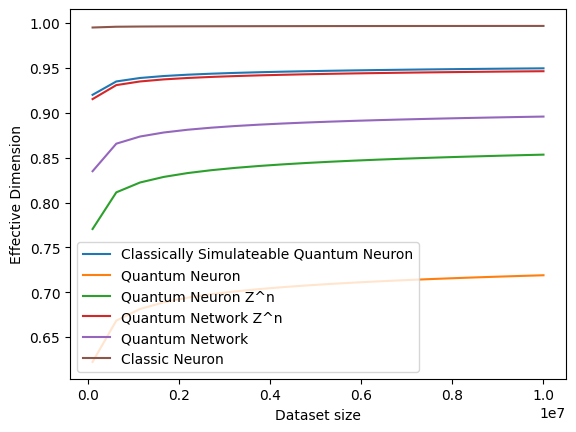

In [40]:

plt.plot(n, global_eff_easy / 5, label="Classically Simulateable Quantum Neuron")
plt.plot(n, global_eff_quantum / 10, label="Quantum Neuron")
plt.plot(n, global_eff_quantum_z_obs/10, label="Quantum Neuron Z^n")
plt.plot(n, global_eff_quantum_qnn_qfm/10, label="Quantum Network Z^n")
plt.plot(n, global_eff_quantum_qnn_qfm_2/10, label="Quantum Network")
plt.plot(n, global_eff_classic/5, label="Classic Neuron")

#plt.plot(n, global_deep_qnn/25, label="Deep (5) Quantum Network")

plt.xlabel("Dataset size")
plt.ylabel("Effective Dimension")
plt.legend()
plt.show()

In [18]:
easy_circ = QNN_builder(5, easy_feature_map, easy_ansatz, depth=1)
easy_circ = make_estimator_qnn(easy_circ)

y = np.random.normal(size=20).T
classical_input = np.array([2*np.random.random(size=(5,20))-1]).T

model = Sequential()

model.add(Dense(1, kernel_initializer='he_normal', use_bias=False, input_shape=(5,)))

model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

classical_wrapper = ClassicalNNWrapper(model, n_inputs=5, n_outputs=1,  output_activation='sigmoid')

global_ed_classical = EffectiveDimension(
    qnn=classical_wrapper,
    weight_samples=50,
    input_samples=50,  # stessi input del quantistico
   
)
global_eff_classic = global_ed_classical.get_effective_dimension(dataset_size=n)

global_ed_easy = EffectiveDimension(
    qnn=easy_circ,
    weight_samples=20,
    input_samples=20 
)
global_eff_easy = global_ed_easy.get_effective_dimension(dataset_size=n)



No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


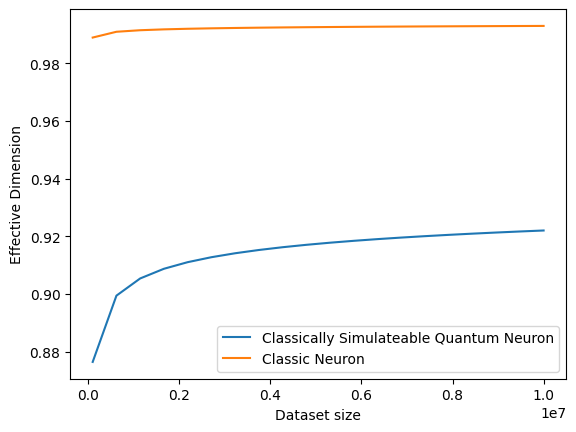

In [19]:
plt.plot(n, global_eff_easy / 5, label="Classically Simulateable Quantum Neuron")

plt.plot(n, global_eff_classic/5, label="Classic Neuron")

#plt.plot(n, global_deep_qnn/25, label="Deep (5) Quantum Network")

plt.xlabel("Dataset size")
plt.ylabel("Effective Dimension")
plt.legend()
plt.show()

# Same effective dimension demonstration

State setting:


$$\hat{x} = \frac{x}{x_{max}+x_{min}}$$


$$ \tilde {x} = \cos^{-1}(\hat{x}) $$


$$ H \vert 0\rangle  = \vert +\rangle_x $$


$$R_z( \tilde {x}) \vert + \rangle =  \vert \psi\rangle$$

$$\vert \psi\rangle =  \frac{1}{\sqrt{2}}\left(  \vert 0\rangle + e^{i \tilde {x}} \vert 1\rangle \right)$$

The effect of the neuron:

$$R_y(\theta)\vert \psi\rangle = \frac{1}{\sqrt{2}}\left(  (\cos \frac{\theta}{2} - e^{i \tilde {x}}\sin \frac{\theta}{2})\vert 0\rangle + (\cos \frac{\theta}{2} + e^{i \tilde {x}}\sin \frac{\theta}{2})\vert 1\rangle \right)$$

Derivation for the probability of measuring the state $ \vert 0\rangle$:

$$p_{0} = \frac{1}{2}(\cos \frac{\theta}{2} - e^{i \tilde {x}}\sin \frac{\theta}{2})  (\cos \frac{\theta}{2} - e^{-i \tilde {x}}\sin \frac{\theta}{2})$$

$$p_{0} = \frac{1}{2}(\cos^2 \frac{\theta}{2} +\sin^2 \frac{\theta}{2} - e^{-i \tilde {x}}\cos \frac{\theta}{2} \sin \frac{\theta}{2} - e^{i \tilde {x}}\cos \frac{\theta}{2} \sin \frac{\theta}{2}) $$

$$p_{0} = \frac{1}{2}(\cos^2 \frac{\theta}{2} +\sin^2 \frac{\theta}{2} -  \cos {\tilde {x}}\sin \theta) $$

$$p_{0} = \frac{1-\cos {\tilde {x}}\sin \theta}{2} $$

The same derivation can be done for the probability of measuring the state $ \vert 1\rangle$:
$$p_{1} = \frac{1+\cos {\tilde {x}}\sin \theta}{2} $$

So the probability of measuring $k$ times the state $ \vert 0\rangle$ in $n$ measuments is:

$$ p(k) = \frac{n!}{(n-k)!k!} p_0^{k} p_1^{n-k} $$

We can define the output function of the neuron as:

$$f(\hat{x}) = 2(\frac{k}{n} - \frac{1}{2})$$

So the distribution of $f( x) $ is obtained as:

$$k = \frac{n}{2}(f(x)+ 1)$$

$$p_f(f)=p_k(k(f))$$

$$p_f(f)  = \frac{n!}{[n-\frac{n}{2}(f(x)+ 1) ]![\frac{n}{2}(f(x)+ 1)]!} p_0^{\frac{n}{2}(f(x)+ 1)} p_1^{n-\frac{n}{2}(f(x)+ 1)}$$

$$p_f(f)  = \frac{n!}{[\frac{n}{2}(1-f(x)) ]![\frac{n}{2}(f(x)+ 1)]!} p_0^{\frac{n}{2}(f(x)+ 1)} p_1^{\frac{n}{2}(1-f(x))}$$

Using the likelihood is:

$$p(y | x, \theta, \sigma_y) = p(y|f(x), \sigma_y) $$

But $f(x)$ is a random variable, we should evaluate $\langle f \rangle(x)$:

$$\langle f \rangle(\hat{x})= 2(\frac{\langle k \rangle}{n} - \frac{1}{2}) =  2(\frac{np_0}{n} - \frac{1}{2})  =- \cos \tilde{x} \sin \theta = \hat{x} \sin \theta $$

$$ Var({\langle f \rangle}) = \frac{4}{n^2}Var(k)=\frac{4}{n^2}np_0p_1=\frac{1-\cos^2 \tilde{x} \sin^2 \theta}{n}=\frac{1-\hat{x}^2\sin^2 \theta}{n}$$

So we can define an effective error for the likelihood:

$$\sigma_{eff} = \sigma_y^2 + \sigma_f^2$$

The likelihood can be expressed as:

$$p(y | x, \theta, \sigma_y) = \mathcal{N}_y(\langle f \rangle (x), \sigma_y^2) p(f(x))$$

Then:

$$ \log p(y | x, \theta, \sigma_y) = -\frac{1}{2}\log(2\pi \sigma_{eff}^2) - \frac{(y-(\langle f \rangle (x))^2}{2\sigma_{eff}^2}$$


$$\frac{\partial }{\partial \theta} \langle f \rangle(\theta) = \hat{x}\cos\theta$$

$$\frac{\partial }{\partial \theta} \sigma_{eff}^2(\theta) = -\frac{\hat{x}^2\sin(2\theta)}{n} = -\frac{2\hat{x}^2\sin\theta\cos\theta}{n}$$

$$I(\theta\mid \hat{x}) = \frac{\hat{x}^2\cos^2\theta}{\sigma_{eff}^2} + \frac{1}{2\sigma_{eff}^4}\left(\frac{2\hat{x}^2\sin\theta\cos\theta}{n}\right)^2$$

$$I(\theta\mid \hat{x}) = \frac{\hat{x}^2\cos^2\theta}{\sigma_{eff}^2(\hat{x})} + \frac{2\hat{x}^4\sin^2\theta\cos^2\theta}{n^2\,\sigma_{eff}^4(\hat{x})}$$

# Classical Neuron
$$f(x;w) = wx$$

$$p(y\mid x;\theta) = \mathcal{N}(y;\, f(x;\theta),\, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(y-f(x;\theta))^2}{2\sigma^2}\right)$$


$$\log p(y\mid x;\theta) = -\frac{1}{2}\log(2\pi\sigma^2) - \frac{(y-f)^2}{2\sigma^2}$$

$$\frac{\partial \log p}{\partial w} = \frac{(y-f)}{\sigma^2}\,x$$

$$(\frac{\partial \log p}{\partial w})^2 = \frac{(y-f)^2}{\sigma^4}\,x^2$$

$$\mathbb{E}_y[(y-f)^2] = \text{Var}(y) = \sigma^2$$

$$I(\theta | x) = \frac{Var(x)}{\sigma^2}$$

# Generalizing in multiple dimensions

## Classical Neuron
$$
\frac{\partial \log p}{\partial w_i} = \frac{(y-f)}{\sigma^2}x_i \quad\Rightarrow\quad I_{ij}(\mathbf{w}) = \mathbb{E}_y\left[\frac{\partial\log p}{\partial w_i}\frac{\partial \log p}{\partial w_j}\right] = \frac{x_i x_j}{\sigma^2}
$$


$$
I(\mathbf{w}\mid\mathbf{x}) = \frac{1}{\sigma^2}\,\mathbf{x}\mathbf{x}^\top
$$

## Quantum Neuron

$$
\langle f\rangle(\mathbf{x};\theta) = \sum_i \hat x_i \sin\theta_i
$$

$$
\frac{\partial \langle f\rangle}{\partial \theta_i} = \hat x_i \cos\theta_i
$$

$$
\frac{\partial \sigma_{eff}^2}{\partial \theta_i} = -\frac{2\hat x_i^2 \sin\theta_i\cos\theta_i}{n}
$$

$$
I_{ij}(\theta) = \frac{1}{\sigma_{eff}^2}\frac{\partial\langle f\rangle}{\partial \theta_i}\frac{\partial\langle f\rangle}{\partial\theta_j} + \frac{1}{2\sigma_{eff}^4}\frac{\partial \sigma_{eff}^2}{\partial\theta_i}\frac{\partial\sigma_{eff}^2}{\partial\theta_j}
$$

## Comparison

$$
I^{classic} = \frac{1}{\sigma^2}\,\mathbf{x}\mathbf{x}^\top, \qquad
I^{quantum} = \frac{1}{\sigma_{eff}^2}\,\mathbf{u}\mathbf{u}^\top + \frac{1}{2\sigma_{eff}^4}\,\mathbf{v}\mathbf{v}^\top
$$

where

$$
u_i = \hat x_i\cos\theta_i, \qquad v_i = \frac{2\hat x_i^2\sin\theta_i\cos\theta_i}{n}
$$

For $n>>1$ we have:

$$
I^{classic} = \frac{1}{\sigma^2}\,\mathbf{x}\mathbf{x}^\top, \qquad
I^{quantum} = \frac{1}{\sigma_{y}^2}\,\mathbf{u}\mathbf{u}^\top
$$

For Appendix B.3 Abbas et al.

$$ d_{\gamma, n} = \bar{r} \qquad n \rightarrow \infty$$

Where $\bar{r}=\max_{\theta \in \Theta} Rank(I(\theta))$

Since the max rank for $I^{quantum}$ is $d$ is reached for $\theta_i = 2n\pi$ for any $i \in {1, 2, ..., d}$ we conclude that both the neurons have same effective dimension.


In [20]:
class ClassicalNNWrapper(NeuralNetwork):
    
    def __init__(self, keras_model, n_inputs: int, n_outputs: int,
                 input_gradients: bool = True, output_activation: str | None = None):
      
        self._model = keras_model
        self._output_activation = output_activation
        
        num_weights = int(keras_model.count_params())
        self._weight_shapes = [w.shape for w in keras_model.get_weights()]
        self._weight_sizes = [int(np.prod(s)) for s in self._weight_shapes]

        super().__init__(
            num_inputs=n_inputs,
            num_weights=num_weights,
            sparse=False,
            output_shape=(n_outputs,),
            input_gradients=input_gradients,
        )

    def _weights_vector_to_keras_list(self, weights_flat: np.ndarray):
       
        weights_flat = np.asarray(weights_flat).reshape(-1)
        out = []
        idx = 0
        for shape, size in zip(self._weight_shapes, self._weight_sizes):
            chunk = weights_flat[idx: idx + size]
            out.append(chunk.reshape(shape))
            idx += size
        return out

    
    def _raw_forward(self, input_data: np.ndarray) -> np.ndarray:
        
        return self._model.predict(input_data, verbose=0)

    def _apply_output_activation(self, raw_output: np.ndarray) -> np.ndarray:
        if self._output_activation is None:
            return raw_output
        if self._output_activation == "sigmoid":
            return 1.0 / (1.0 + np.exp(-raw_output))
       

    def _forward(self, input_data: np.ndarray, weights: np.ndarray) -> np.ndarray:
        
        self._model.set_weights(self._weights_vector_to_keras_list(weights))
        raw_output = self._raw_forward(input_data)
        return self._apply_output_activation(raw_output)

    def _backward(self, input_data: np.ndarray, weights: np.ndarray):
        
        self._model.set_weights(self._weights_vector_to_keras_list(weights))

        n = input_data.shape[0]
        x = tf.convert_to_tensor(input_data, dtype=tf.float32)

        with tf.GradientTape(persistent=True) as tape:
            tape.watch(x)
            raw_output = self._model(x, training=False)  

            if self._output_activation == "sigmoid":
                output = tf.sigmoid(raw_output)
            else:
                output = raw_output

            output_size = output.shape[1]

       
        weight_grads = []
        for w in self._model.trainable_weights:
            jac = tape.jacobian(output, w)          
            jac_flat = tf.reshape(jac, (n, output_size, -1))
            weight_grads.append(jac_flat)
        weight_grad = tf.concat(weight_grads, axis=2).numpy()

       
        input_grad = None
        if self.input_gradients:
           
            input_grad = tape.batch_jacobian(output, x).numpy()  
        del tape
        return input_grad, weight_grad

In [21]:

easy_circ = QNN_builder(5, easy_feature_map, quantum_ansatz, depth=1)
easy_circ = make_estimator_qnn(easy_circ)
easy_easy_circ = QNN_builder(5, easy_feature_map, easy_ansatz, depth=1)
easy_easy_circ = make_estimator_qnn(easy_easy_circ)


easy_circ_par = QNN_builder(5, easy_feature_map, quantum_ansatz, depth=1)
easy_circ_par = make_estimator_qnn(easy_circ_par, False)
easy_easy_circ_par = QNN_builder(5, easy_feature_map, easy_ansatz, depth=1)
easy_easy_circ_par = make_estimator_qnn(easy_easy_circ_par, False)
model = Sequential()
model = Sequential()


model.add(Dense(5, kernel_initializer='he_normal', use_bias=False, input_shape=(1,)))
model.add(Activation('tanh'))
model.add(Dense(1, kernel_initializer='he_normal', use_bias=False, input_shape=(5,)))
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

classical_wrapper = ClassicalNNWrapper(model, n_inputs=1, n_outputs=1,  output_activation='sigmoid')

classical_input = np.array([2*np.random.rand(20)-1]).T
quantum_input = np.array([2*np.random.rand(20)-1]*5).T
global_ed_classical = EffectiveDimension(
    qnn=classical_wrapper,
    weight_samples=20,
    input_samples=classical_input,
   
)

global_eff_classic_tanh = global_ed_classical.get_effective_dimension(dataset_size=n)

model = Sequential()

model.add(Dense(5, kernel_initializer='he_normal', use_bias=False, input_shape=(1,)))
model.add(Activation('sigmoid'))
model.add(Dense(1, kernel_initializer='he_normal', use_bias=False, input_shape=(5,)))
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

classical_wrapper = ClassicalNNWrapper(model, n_inputs=1, n_outputs=1,  output_activation='sigmoid')
global_ed_classical = EffectiveDimension(
    qnn=classical_wrapper,
    weight_samples=20,
    input_samples=classical_input,  
   
)
global_eff_classic_sig =  global_ed_classical.get_effective_dimension(dataset_size=n)

model = Sequential()

model.add(Dense(5, kernel_initializer='he_normal', use_bias=False, input_shape=(1,)))
model.add(Lambda(lambda x: tf.sin(x)))
model.add(Dense(1, kernel_initializer='he_normal', use_bias=False, input_shape=(5,)))
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

classical_wrapper = ClassicalNNWrapper(model, n_inputs=1, n_outputs=1,  output_activation='sigmoid')

classical_input = np.array([2*np.random.rand(20)-1]).T
quantum_input = np.array([2*np.random.rand(20)-1]*5).T
global_ed_classical = EffectiveDimension(
    qnn=classical_wrapper,
    weight_samples=20,
    input_samples=classical_input,  
   
)

global_eff_classic_sin = global_ed_classical.get_effective_dimension(dataset_size=n)

model = Sequential()

model.add(Dense(5, kernel_initializer='he_normal', use_bias=False, input_shape=(1,)))
model.add(Lambda(lambda x: tf.cos(x)))
model.add(Dense(1, kernel_initializer='he_normal', use_bias=False, input_shape=(5,)))
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

classical_wrapper = ClassicalNNWrapper(model, n_inputs=1, n_outputs=1,  output_activation='sigmoid')

global_ed_classical_cos = EffectiveDimension(
    qnn=classical_wrapper,
    weight_samples=20,
    input_samples=classical_input,
   
)
global_eff_classic_cos =  global_ed_classical_cos.get_effective_dimension(dataset_size=n)


model = Sequential()

model.add(Dense(5, kernel_initializer='he_normal', use_bias=False, input_shape=(1,)))
model.add(Dense(1, kernel_initializer='he_normal', use_bias=False, input_shape=(5,)))
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

classical_wrapper = ClassicalNNWrapper(model, n_inputs=1, n_outputs=1,  output_activation='sigmoid')

classical_input = np.array([2*np.random.rand(20)-1]).T
quantum_input = np.array([2*np.random.rand(20)-1]*5).T
global_ed_classical = EffectiveDimension(
    qnn=classical_wrapper,
    weight_samples=20,
    input_samples=classical_input, 
   
)

global_eff_classic_no_act = global_ed_classical.get_effective_dimension(dataset_size=n)

global_ed_easy = EffectiveDimension(
    qnn=easy_circ,
    weight_samples=20,
    input_samples=quantum_input
)
global_eff_easy = global_ed_easy.get_effective_dimension(dataset_size=n)

global_ed_easy_easy = EffectiveDimension(
    qnn=easy_easy_circ,
    weight_samples=20,
    input_samples=quantum_input
)
global_eff_easy_easy = global_ed_easy_easy.get_effective_dimension(dataset_size=n)


global_ed_easy_par = EffectiveDimension(
    qnn=easy_circ_par,
    weight_samples=20,
    input_samples=quantum_input
)
global_eff_easy_par = global_ed_easy_par.get_effective_dimension(dataset_size=n)

global_ed_easy_easy_par = EffectiveDimension(
    qnn=easy_easy_circ_par,
    weight_samples=20,
    input_samples=quantum_input
)
global_eff_easy_easy_par = global_ed_easy_easy_par.get_effective_dimension(dataset_size=n)



No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_reg

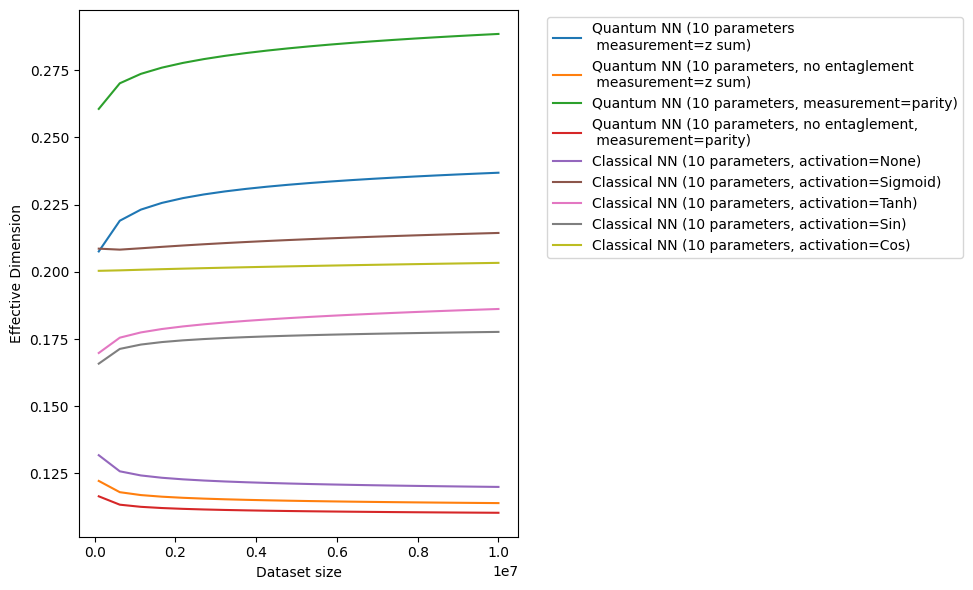

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(n, global_eff_easy / 10, label="Quantum NN (10 parameters\n measurement=z sum)")
plt.plot(n, global_eff_easy_easy / 10, label="Quantum NN (10 parameters, no entaglement \n measurement=z sum)")
plt.plot(n, global_eff_easy_par / 10, label="Quantum NN (10 parameters, measurement=parity)")
plt.plot(n, global_eff_easy_easy_par / 10, label="Quantum NN (10 parameters, no entaglement, \n measurement=parity)")

plt.plot(n, global_eff_classic_no_act/10, label="Classical NN (10 parameters, activation=None)")
plt.plot(n, global_eff_classic_sig/10, label="Classical NN (10 parameters, activation=Sigmoid)")
plt.plot(n, global_eff_classic_tanh/10, label="Classical NN (10 parameters, activation=Tanh)")
plt.plot(n, global_eff_classic_sin/10, label="Classical NN (10 parameters, activation=Sin)")
plt.plot(n, global_eff_classic_cos/10, label="Classical NN (10 parameters, activation=Cos)")

#plt.plot(n, global_deep_qnn/25, label="Deep (5) Quantum Network")

plt.xlabel("Dataset size")
plt.ylabel("Effective Dimension")


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()

# New interpretation of QNN

## Circuit

$$|00\rangle \xrightarrow{H \otimes H} \xrightarrow{R_z(x) \otimes R_z(x)} \xrightarrow{R_y(\theta_1) \otimes R_y(\theta_2)} \xrightarrow{\text{CNOT}} \xrightarrow{R_y(\theta_3) \otimes R_y(\theta_4)} |\psi_f\rangle$$

Rotations:

$$R_y(\theta) = \begin{pmatrix} \cos\left(\frac{\theta}{2}\right) & -\sin\left(\frac{\theta}{2}\right) \\ \sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right) \end{pmatrix}$$

$$R_z(x) = \begin{pmatrix} e^{-i x/2} & 0 \\ 0 & e^{i x/2} \end{pmatrix}$$

---

### Hadamard


$$|00\rangle \xrightarrow{H \otimes H} \frac{1}{2} \bigl( |00\rangle + |01\rangle + |10\rangle + |11\rangle \bigr)$$

---

### $R_z(x)$ 

$$\frac{1}{2} \bigl( e^{-ix}|00\rangle + |01\rangle + |10\rangle + e^{ix}|11\rangle \bigr)$$

---

### $R_y(\theta_1) \otimes R_y(\theta_2)$

We obtain $|\psi_3\rangle = a_{00}|00\rangle + a_{01}|01\rangle + a_{10}|10\rangle + a_{11}|11\rangle$, where:

$$a_{00} = \frac{e^{-ix}}{2} \left[ \left(e^{ix}\sin\left(\frac{\theta_1}{2}\right)\sin\left(\frac{\theta_2}{2}\right) - \sin\left(\frac{\theta_1+\theta_2}{2}\right)\right) e^{ix} + \cos\left(\frac{\theta_1}{2}\right)\cos\left(\frac{\theta_2}{2}\right) \right]$$

$$a_{01} = \frac{e^{-ix}}{2} \left[ \left(-e^{ix}\sin\left(\frac{\theta_1}{2}\right)\cos\left(\frac{\theta_2}{2}\right) + \cos\left(\frac{\theta_1+\theta_2}{2}\right)\right) e^{ix} + \sin\left(\frac{\theta_2}{2}\right)\cos\left(\frac{\theta_1}{2}\right) \right]$$

$$a_{10} = \frac{e^{-ix}}{2} \left[ \left(-e^{ix}\sin\left(\frac{\theta_2}{2}\right)\cos\left(\frac{\theta_1}{2}\right) + \cos\left(\frac{\theta_1+\theta_2}{2}\right)\right) e^{ix} + \sin\left(\frac{\theta_1}{2}\right)\cos\left(\frac{\theta_2}{2}\right) \right]$$

$$a_{11} = \frac{e^{-ix}}{2} \left[ \left(e^{ix}\cos\left(\frac{\theta_1}{2}\right)\cos\left(\frac{\theta_2}{2}\right) + \sin\left(\frac{\theta_1+\theta_2}{2}\right)\right) e^{ix} + \sin\left(\frac{\theta_1}{2}\right)\sin\left(\frac{\theta_2}{2}\right) \right]$$

---

###  CNOT

The $\text{CNOT}$ swipes the amplitudes of $|10\rangle$ and $|11\rangle$:

$$\begin{aligned}
b_{00} &= a_{00} \\
b_{01} &= a_{01} \\
b_{10} &= a_{11} \\
b_{11} &= a_{10}
\end{aligned}$$

Then, after the $\text{CNOT}$:

$$|\psi_4\rangle = b_{00}|00\rangle + b_{01}|01\rangle + b_{10}|10\rangle + b_{11}|11\rangle$$

---

###  $R_y(\theta_3) \otimes R_y(\theta_4)$

$$\begin{aligned}
c_3 &= \cos\left(\frac{\theta_3}{2}\right), \quad s_3 = \sin\left(\frac{\theta_3}{2}\right) \\
c_4 &= \cos\left(\frac{\theta_4}{2}\right), \quad s_4 = \sin\left(\frac{\theta_4}{2}\right)
\end{aligned}$$

Final amplitudes:

$$\begin{aligned}
\psi_{00} &= c_3 c_4 b_{00} - s_3 c_4 b_{10} - s_4 c_3 b_{01} + s_3 s_4 b_{11} \\
\psi_{01} &= s_4 c_3 b_{00} + c_3 c_4 b_{01} - s_3 s_4 b_{10} - s_3 c_4 b_{11} \\
\psi_{10} &= s_3 c_4 b_{00} - s_3 s_4 b_{01} + c_3 c_4 b_{10} - c_3 s_4 b_{11} \\
\psi_{11} &= s_3 s_4 b_{00} + s_3 c_4 b_{01} + c_3 s_4 b_{10} + c_3 c_4 b_{11}
\end{aligned}$$

---

### Final state


$$|\psi_f\rangle = \psi_{00}|00\rangle + \psi_{01}|01\rangle + \psi_{10}|10\rangle + \psi_{11}|11\rangle$$

### Measurement

$$\langle O\rangle = \text{Sign}\left( |\psi_{00}|^2 + |\psi_{11}|^2 - |\psi_{01}|^2 - |\psi_{10}|^2\right)$$

$$\langle O\rangle = \text{Sign}\left( w \cdot x\right)$$

Where $x=(|\psi_{00}|^2, ..., |\psi_{11}|^2)$ and $w=(1, -1, -1, 1)$


### Interpretation 

In the end we will measure the parity of the bits, so you can see from the formula that the network behaves as a feature map that creates the probabilities $x=(|\psi_{00}|^2, ..., |\psi_{11}|^2)$ and that weights them with vector  $w=(1, -1, -1, 1)$. Since the vector is fixed, we can see the observable itself as neuron (a dumb one since it is not trainable).
If this interpretation of the neuron works, and we build a classical neural network to emulate it as following (same number of parameters):

```

model = Sequential()
model.add(Dense(2, kernel_initializer='he_normal', use_bias=False, input_shape=(1,)))
model.add(Activation("sigmoid"))
model.add(Dense(4, kernel_initializer='he_normal', use_bias=False, input_shape=(1,)))
model.add(Activation("sigmoid"))
model.add(Lambda(random_projection, output_shape=(1,)))
model.add(Activation("sigmoid"))
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])
```
Data tells us that there is no gain in the effective dimension by using a QNN



In [23]:
def compute_fisher(model, X, y):
    # Inizializzazione
    fisher = None
    
    # Batch size = 1 è corretto per la Fisher empirica punto per punto
    dataset = tf.data.Dataset.from_tensor_slices((X, y)).batch(1)
    
    for x_batch, y_batch in dataset:
        x_batch = tf.cast(x_batch, tf.float32)
        
        with tf.GradientTape() as tape:
            # Non serve fare tape.watch() sulle variabili tracciabili del modello
            preds = model(x_batch, training=False)
            loss = tf.keras.losses.mse(y_batch, preds)
            
        # 1. Calcola il gradiente RISPETTO AI PARAMETRI
        grads = tape.gradient(loss, model.trainable_variables)
        
        if grads is None or any(g is None for g in grads):
            continue  
        
        # 3. Appiattisci e concatena i gradienti di tutti i layer
        g = np.concatenate([g_layer.numpy().flatten() for g_layer in grads])
        
        # Inizializza la matrice della dimensione corretta (D x D)
        if fisher is None:
            num_params = g.size
            print(f"Numero di parametri del modello: {num_params}")
            # Alert memoria
            if num_params > 20000:
                print("Attenzione: Il modello è grande. Rischio Out of Memory!")
            fisher = np.zeros((num_params, num_params))
            
        # Accumula il prodotto esterno
        fisher += np.outer(g, g)
        
    # Media sul numero totale di campioni
    fisher /= len(X)
    
    return fisher
    
def effective_dimension(F, n):

    d = F.shape[0]

    kappa = n / (2 * np.pi * np.log(n))

    #normalization
    F_hat = d * F / np.trace(F)

    I = np.eye(d)

    M = I + kappa * F_hat

    sign, logdet = np.linalg.slogdet(M)

    d_eff = logdet / np.log(kappa)

    return d_eff

model = Sequential()

model.add(Dense(1, kernel_initializer='he_normal', use_bias=False, input_shape=(5,)))

model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

f= compute_fisher(model, feature_map(x_training), y_training)
print(effective_dimension(f, 10000000)/5)
ef = []
n = [i*10e6 for i in np.linspace(0.01,1,20)]

for i in n:
    ef.append(effective_dimension(f, i)/5)

t = f.trace()

eigvals, eigvecs = np.linalg.eigh(f)

for i in range(len(eigvals)):
    M = np.sort(eigvals)[::-1][i]
    M/t
    print(f'Information in eigenvalue {i}: {M/t:.2f}')


Numero di parametri del modello: 5
0.9431452942017786
Information in eigenvalue 0: 0.45
Information in eigenvalue 1: 0.33
Information in eigenvalue 2: 0.14
Information in eigenvalue 3: 0.07
Information in eigenvalue 4: 0.01


/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
n = [i*10e6 for i in np.linspace(0.01,1,20)]
def quantum_ansatz(N):
    theta = ParameterVector('theta', 2*N)
    qc = QuantumCircuit(N)
    for i in range(N):
        qc.ry(theta[i], i)
   
    for i in range(N-1):
            for j in range(i+1,N):
                qc.cx(i, j)
                
    for i in range(N):
        qc.ry(theta[i+N], i)
    
    return qc
    
def random_projection(x):
    #weights = tf.random.uniform((tf.shape(x)[-1],), minval=-1, maxval=1)
    weights = tf.constant([1, 1, -1, -1], dtype=tf.float32)
    return tf.reduce_sum(x * weights, axis=-1, keepdims=True)  # shape (batch_size, 1)


model = Sequential()
model.add(Dense(4, kernel_initializer='he_normal', use_bias=False, input_shape=(1,)))
model.add(Activation("sigmoid"))
model.add(Lambda(random_projection, output_shape=(1,)))
#model.add(Activation("sigmoid"))
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])


quantum_input = np.array([2*np.random.rand(100)-1]*2).T

easy_circ_par = QNN_builder(2, easy_feature_map, quantum_ansatz, depth=1)
easy_circ_par = make_estimator_qnn(easy_circ_par, False)
global_ed_easy_par = EffectiveDimension(
    qnn=easy_circ_par,
    weight_samples=300,
    input_samples=quantum_input
)
global_eff_easy_par = global_ed_easy_par.get_effective_dimension(dataset_size=n)


N = 300
x = 2*np.random.rand(N).T-1
y = np.random.normal(size=N).T

ed = np.zeros((len(n), N))
for i in range(N):
    f= compute_fisher(model, x, y)
    for j, n_curr in enumerate(n):
        ed_curr = effective_dimension(f, n_curr)
        ed[j, i] = ed_curr



/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri del modello: 4
Numero di parametri 

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


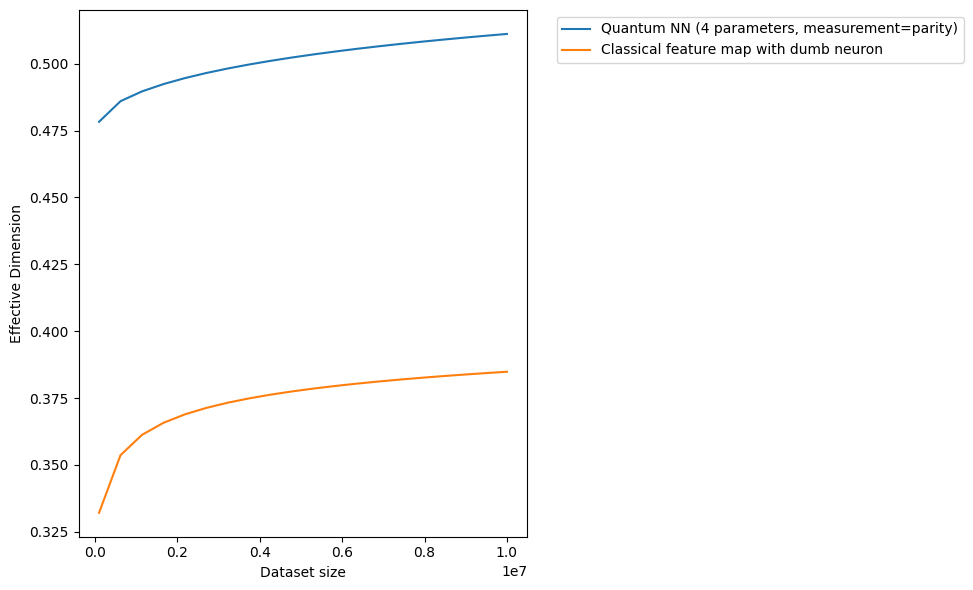

In [64]:

quantum_input = np.array([2*np.random.rand(50)-1]*2).T

easy_circ_par = QNN_builder(2, easy_feature_map, quantum_ansatz, depth=1)
easy_circ_par = make_estimator_qnn(easy_circ_par, False)
global_ed_easy_par = EffectiveDimension(
    qnn=easy_circ_par,
    weight_samples=50,
    input_samples=quantum_input
)
global_eff_easy_par = global_ed_easy_par.get_effective_dimension(dataset_size=n)

plt.figure(figsize=(10, 6))

plt.plot(n, global_eff_easy_par / 4, label="Quantum NN (4 parameters, measurement=parity)")

plt.plot(n, np.mean(ed, axis=1)/4, label="Classical feature map with dumb neuron")

plt.xlabel("Dataset size")
plt.ylabel("Effective Dimension")

# Posiziona la legenda fuori a destra
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# --- Modifica 2: Ottimizza i margini per non tagliare la legenda ---
plt.tight_layout()

plt.show()

In [24]:

def quantum_ansatz(N):
    theta = ParameterVector('theta', 5*N)
    qc = QuantumCircuit(N)
    for i in range(N):
        qc.ry(theta[i], i)
   
    for i in range(N-1):
            for j in range(i+1,N):
                qc.cx(i, j)
                
    for i in range(N):
        qc.ry(theta[i+N], i)

    for i in range(N-1):
            for j in range(i+1,N):
                qc.cx(i, j)
                
    for i in range(N):
        qc.ry(theta[i+N], i)

    for i in range(N-1):
            for j in range(i+1,N):
                qc.cx(i, j)
                
    for i in range(N):
        qc.ry(theta[i+N], i)

    for i in range(N-1):
            for j in range(i+1,N):
                qc.cx(i, j)
                
    for i in range(N):
        qc.ry(theta[i+N], i)
    
    return qc


/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del modello: 10
Numero di parametri del mode

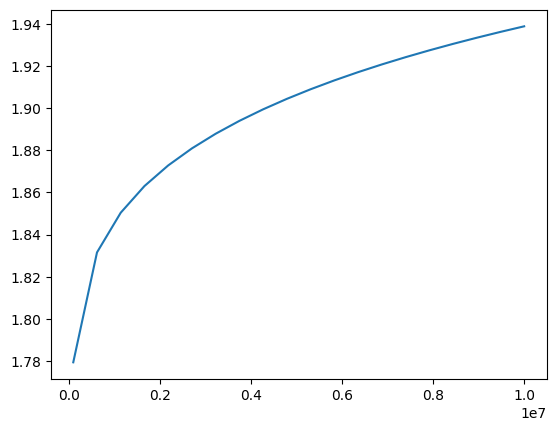

In [22]:
def random_projection(x):
    #weights = tf.random.uniform((tf.shape(x)[-1],), minval=-1, maxval=1)
    weights = tf.constant([1, 1, -1, -1], dtype=tf.float32)
    return tf.reduce_sum(x * weights, axis=-1, keepdims=True)  # shape (batch_size, 1)


plt.plot(n, global_eff_easy_par)
model = Sequential()
model.add(Dense(2, kernel_initializer='he_normal', use_bias=False, input_shape=(1,)))
model.add(Activation("sigmoid"))
model.add(Dense(4, kernel_initializer='he_normal', use_bias=False, input_shape=(2,)))
model.add(Activation("sigmoid"))
model.add(Lambda(random_projection, output_shape=(1,)))
#model.add(Activation("sigmoid"))
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

N = 200
x = 2*np.random.rand(N).T-1
y = np.random.normal(size=N).T

ed = np.zeros((len(n), N))
for i in range(N):
    f= compute_fisher(model, x, y)
    for j, n_curr in enumerate(n):
        ed_curr = effective_dimension(f, n_curr)
        ed[j, i] = ed_curr




No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


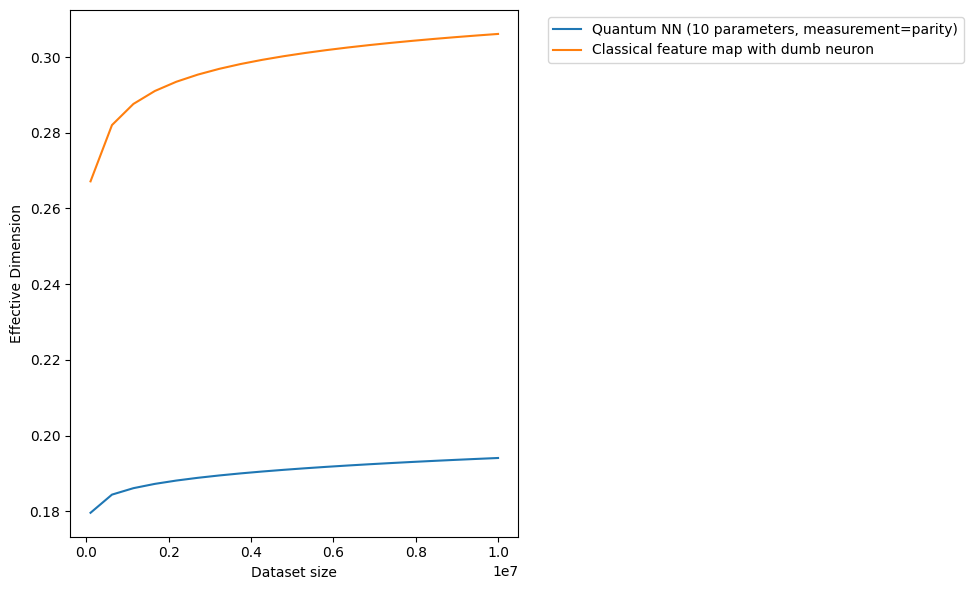

In [27]:
quantum_input = np.array([2*np.random.rand(50)-1]*2).T

easy_circ_par = QNN_builder(2, easy_feature_map, quantum_ansatz, depth=1)
easy_circ_par = make_estimator_qnn(easy_circ_par, False)
global_ed_easy_par = EffectiveDimension(
    qnn=easy_circ_par,
    weight_samples=20,
    input_samples=quantum_input
)
global_eff_easy_par = global_ed_easy_par.get_effective_dimension(dataset_size=n)

plt.figure(figsize=(10, 6))

plt.plot(n, global_eff_easy_par / 10, label="Quantum NN (10 parameters, measurement=parity)")

plt.plot(n, np.mean(ed, axis=1)/10, label="Classical feature map with dumb neuron")

plt.xlabel("Dataset size")
plt.ylabel("Effective Dimension")

# Posiziona la legenda fuori a destra
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# --- Modifica 2: Ottimizza i margini per non tagliare la legenda ---
plt.tight_layout()

plt.show()